# Imports & Helper

In [1]:
# The following are my 'standard copy-paste' imports
# a bit overkill for the example here.
import os, sys, yaml, h5py, pickle, warnings

# Set number of threads
os.environ['KMP_DUPLICATE_LIB_OK']='True' # uncomment this line if omp error occurs on OSX for python 3
os.environ['OMP_NUM_THREADS']='4' # set number of OpenMP threads to run in parallel
os.environ['MKL_NUM_THREADS']='4' # set number of MKL threads to run in parallel

# Math
import numpy as np
np.set_printoptions(precision=3) ## print precision
## random numbers
from numpy.random import default_rng 



# misc
from tqdm.notebook import tqdm, trange ## timing

In [2]:
%matplotlib inline 
#ipy magic for plotting in ipynb; other options are available

import matplotlib as mpl
from matplotlib import rcParams # global parameters of plot
from matplotlib import cm, colors # colormaps and colors for matplotlib
import matplotlib.pyplot as plt # matplotlib

from matplotlib import patches, transforms
import matplotlib.transforms as mtransforms

# define directory where to save figures
fig_dir = "/Users/psch/Work/Figures/plotting_intro/publication"
os.makedirs(fig_dir, exist_ok=True)

## Misc plotting def

In [3]:
# Use style sheet
plt.style.use("./everyday_stylesheet.mplstyle")
#plt.style.use("./stylesheet.mplstyle")

# Misc global definitions
equivec      = np.linspace(0,1,11)[1:]
golden_ratio = (np.sqrt(5)+1)/2

# Some Definitions

SMALL_SIZE   = '20'
MEDIUM_SIZE  = '22'
LARGE_SIZE   = "24"
MAJOR_WIDTH  = 2
MAJOR_LENGTH = 8
MINOR_WIDTH  = 1.9
MINOR_LENGTH = 4
LINE_WIDTH   = 1.5

inch      = 1
a4_width  = 8.3*inch
a3_height = 11.7*inch

4/golden_ratio

2.472135954999579

# Making a nice(?) figure 
**My personal workflow**

## "Load Data"

In [4]:
# Usually here I load the processed(!) data
# here, we are going to generate some mock data for later plotting
seed = 13*17
rng  = default_rng(seed)

omega = 2*np.pi
decay_rate = 1e-2

tvec = np.linspace(0, 1000, 10_001)
cycles_vec = tvec*omega

Avec = np.exp(-tvec*decay_rate)*(10 + 2* np.cos(omega*tvec) )
Avec *= (1+0.04*rng.normal(size=Avec.size))

# 2d data set
xvec = np.linspace(-10,10, 10_001)
yvec = np.linspace(0,1,101)

xarr, yarr = np.meshgrid(xvec, yvec, indexing="ij")

drift_arr = 3*yarr+4*np.sin(omega*yarr)
var_arr   = 0.1+5*yarr

carr = (np.exp(- (xarr+drift_arr)**2/var_arr ) - np.exp(- (xarr-drift_arr)**2/var_arr ))/np.sqrt(var_arr)
carr *= 1/carr.max()
carr += 0.1*rng.normal(size=carr.shape)

## Stare at data

### 1d

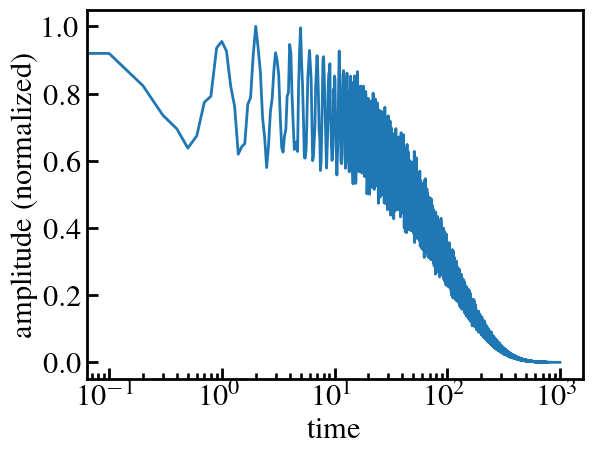

In [5]:
fig, ax = plt.subplots( )

ax.plot(tvec, Avec/Avec.max())
ax.set_xscale("log")

ax.set_xlabel(r"time")
ax.set_ylabel(r"amplitude (normalized)")
plt.show()

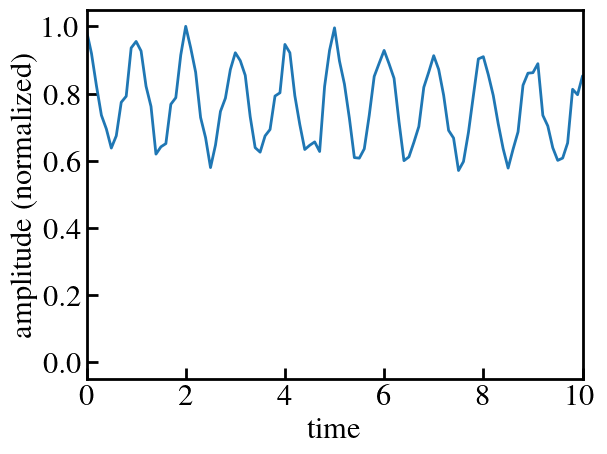

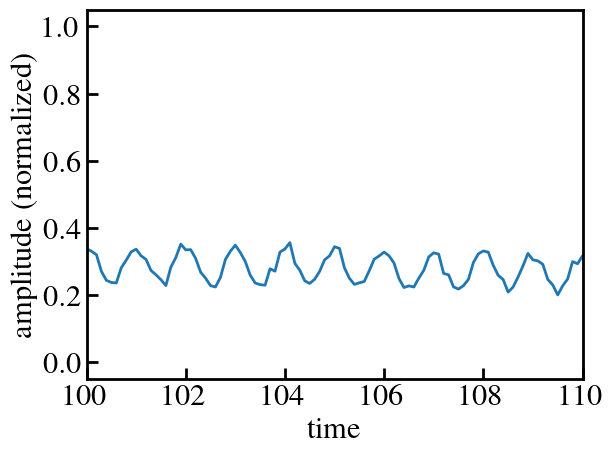

In [6]:
fig, ax = plt.subplots(figsize=(5,4))

ax.plot(tvec, Avec/Avec.max())
ax.set_xlim(0,10)

ax.set_xlabel(r"time")
ax.set_ylabel(r"amplitude (normalized)")
plt.show()
fig, ax = plt.subplots()

ax.plot(tvec, Avec/Avec.max())
ax.set_xlim(100,110)

ax.set_xlabel(r"time")
ax.set_ylabel(r"amplitude (normalized)")
plt.show()

### 2d

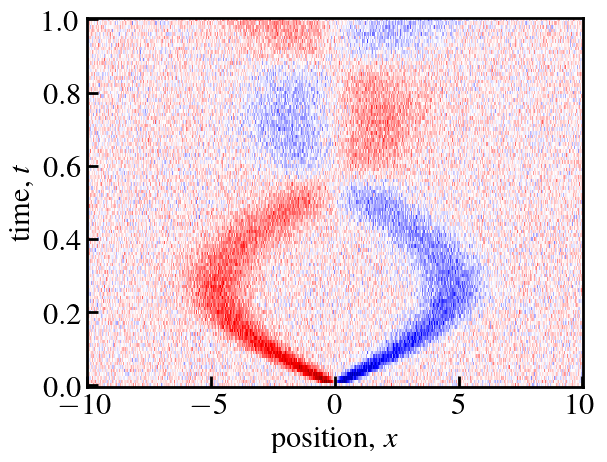

In [7]:
fig, ax = plt.subplots()

ax.pcolormesh(
    xarr,
    yarr,
    carr,
    cmap=cm.seismic
)
ax.set_xlabel(r"position, $x$")
ax.set_ylabel(r"time, $t$")
plt.show()

## Nice Figures

### Subplots

#### 1d plot

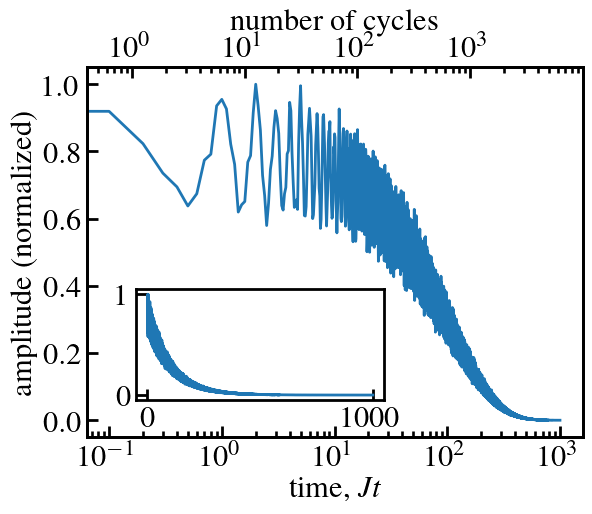

In [8]:
# Main Plot
fig, ax = plt.subplots()



axin = ax.inset_axes([0.1,0.1,0.5,0.3])
axx = ax.twiny() # secondary axis in units of number of cycles

for axs in (ax, axin):
    axs.plot(tvec, Avec/Avec.max())

ax.set_xscale("log")
xlim_t = ax.get_xlim()

axx.set_xscale("log")
axx.set_xlim(xlim_t[0]*omega, xlim_t[1]*omega)
axx.set_xlabel(r"number of cycles")


ax.set_xlabel(r"time, $Jt$")
ax.set_ylabel(r"amplitude (normalized)")
ax.tick_params(which="both", axis="x", pad=5)
plt.show()


In [9]:
def main_fig(ax, axin_coords=[0.1,0.1,0.5,0.3]):
    axin = ax.inset_axes(axin_coords)
    axx = ax.twiny() # secondary axis in units of number of cycles

    for axs in (ax, axin):
        axs.plot(tvec, Avec/Avec.max())

    ax.set_xscale("log")
    xlim_t = ax.get_xlim()

    axx.set_xscale("log")
    axx.set_xlim(xlim_t[0]*omega, xlim_t[1]*omega)
    axx.set_xlabel(r"number of cycles", labelpad=20)


    ax.set_xlabel(r"time, $Jt$")
    ax.set_ylabel(r"amplitude"+"\n"+r"(normalized)")
    ax.tick_params(which="both", axis="x", pad=5)
    
    return ax, axx, axin

##### Subplots

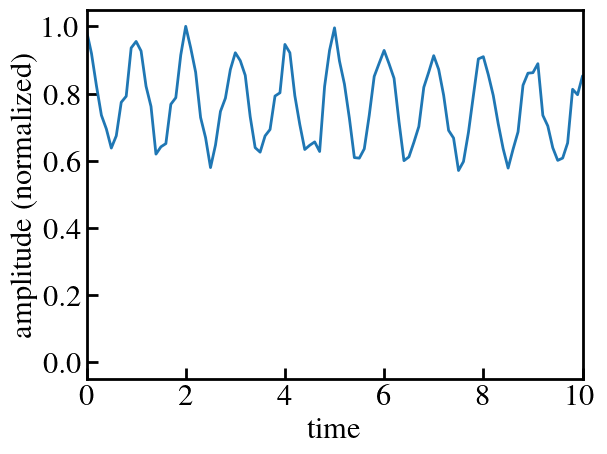

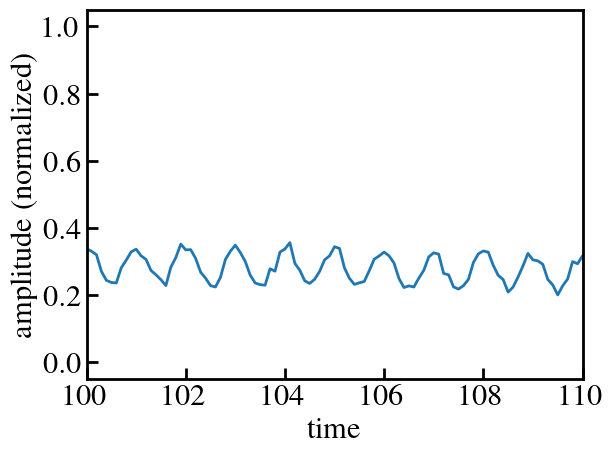

In [10]:
fig, ax = plt.subplots()

ax.plot(tvec, Avec/Avec.max())
ax.set_xlim(0,10)

ax.set_xlabel(r"time")
ax.set_ylabel(r"amplitude (normalized)")
plt.show()
fig, ax = plt.subplots()

ax.plot(tvec, Avec/Avec.max())
ax.set_xlim(100,110)

ax.set_xlabel(r"time")
ax.set_ylabel(r"amplitude (normalized)")
plt.show()

In [11]:
def sub(ax, xmin, xdiff=10):
    
    nlow, nhigh = np.abs(tvec-xmin).argmin(), np.abs(tvec-xmin-xdiff).argmin()
    
    ax.plot(tvec[nlow:nhigh], Avec[nlow:nhigh]/Avec.max())
    ax.set_xlim(xmin, xmin+xdiff)
    
    ax.set_xlabel(r"time")
    ax.set_ylabel(r"amplitude")
    
    axx = ax.twiny() # secondary axis in units of number of cycles

    axx.set_xlim(xlim_t[0]*omega, xlim_t[1]*omega)
    axx.set_xlabel(r"number of cycles")
    
    return *ax.get_xlim(), *ax.get_ylim()

#### 2D plot

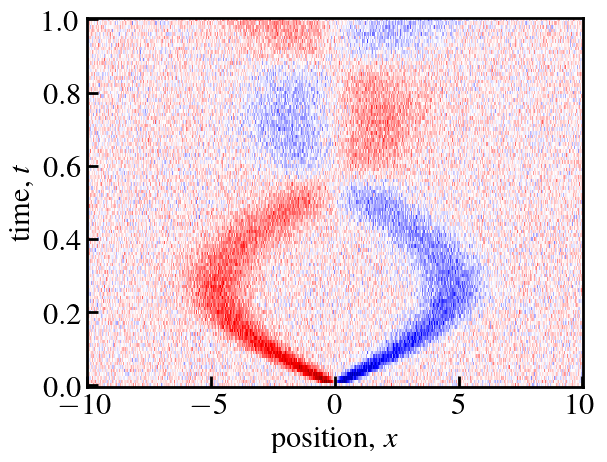

In [12]:
fig, ax = plt.subplots()

ax.pcolormesh(
    xarr,
    yarr,
    carr,
    cmap=cm.seismic
)
ax.set_xlabel(r"position, $x$")
ax.set_ylabel(r"time, $t$")
plt.show()

### Full figure

#### Preparation

In [13]:
def indicate_inset(
    ax, 
    axin,
    coords,
    lw=2,
    path_kwargs={"ls":"-","color":"k", "alpha":0.5, "zorder":1}
):
    
    x0, y0, w, h = coords
    #print(coords)
    rect, _ = ax.indicate_inset(
        [x0, y0, w, h], 
        #inset_ax = ax_zoom,
        edgecolor="k",
        linewidth=lw,
    )

    low, high = axin.get_ylim()
    left, right = axin.get_xlim()
    

    ind1 = patches.ConnectionPatch(
        xyA=(x0,y0), 
        xyB=(left, low), 
        axesA=ax, 
        axesB=axin,
        coordsA="data", 
        **path_kwargs
    )
    
    ind2 = patches.ConnectionPatch(
        xyA=(x0+w,y0), 
        xyB=(right, low), 
        axesA=ax, 
        axesB=axin,
        coordsA="data", 
        **path_kwargs
    )
    ax.add_patch(ind1)
    ax.add_patch(ind2)
    
    #done

In [14]:
cmap = cm.RdBu_r

#### Plot

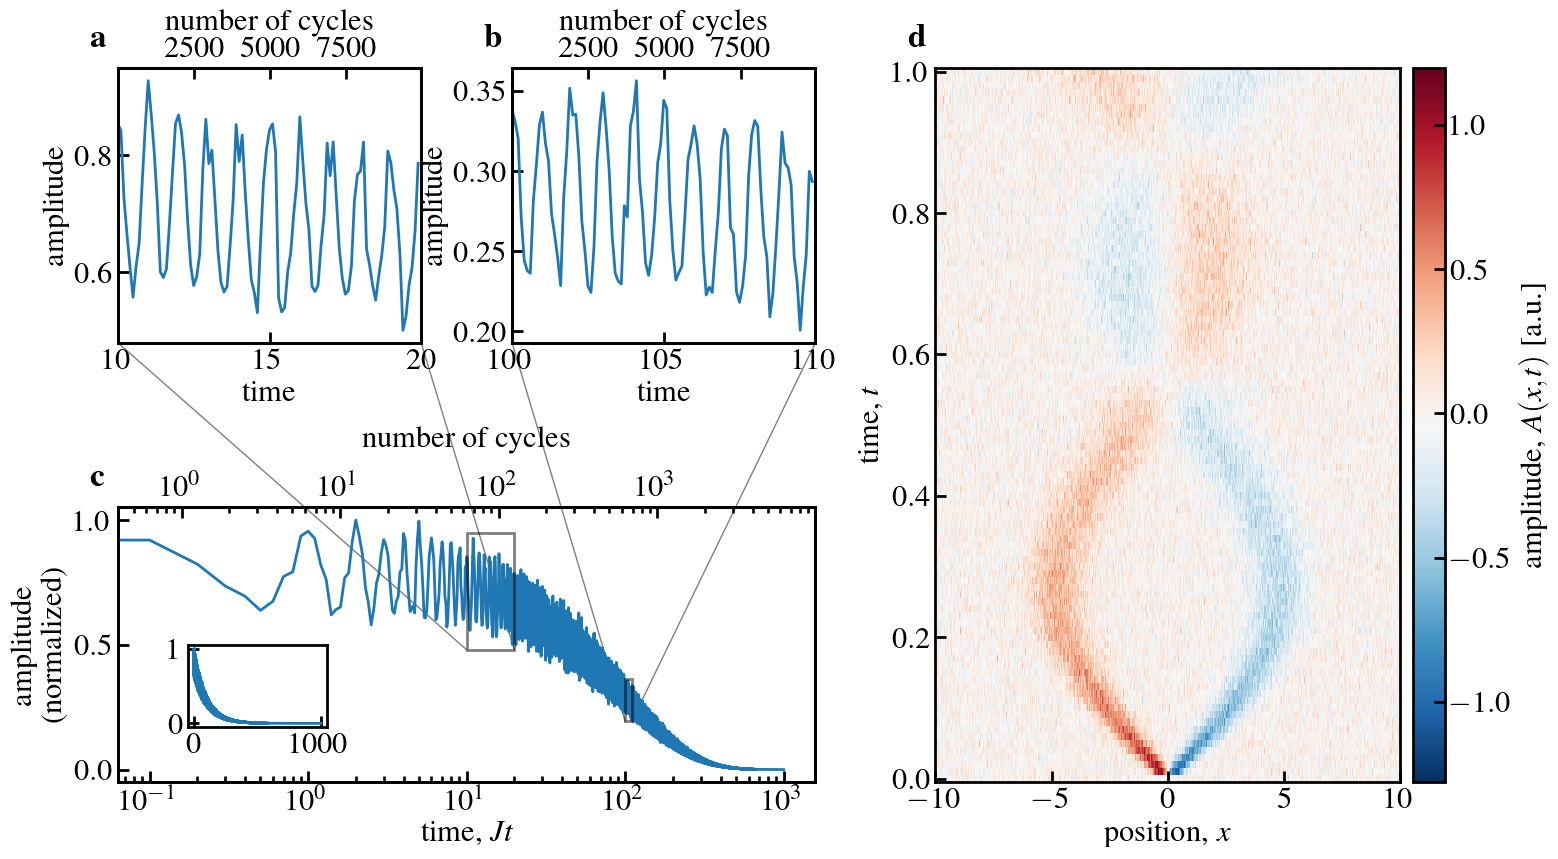

In [17]:
fig = plt.figure(
    figsize=(15,15/golden_ratio),
    #dpi=50
)

fig_t, fig_2d = fig.subfigures(
    ncols=2,
    width_ratios=(1.5,1)
)

#=====================
# Real time data
#=====================
ax_dict = fig_t.subplot_mosaic(
    [["zoom_1", "zoom_2"],["main", "main"]],
)
fig_t.subplots_adjust(
    hspace=.6,
    wspace=0.3
)


# Main Plot
#=====================
main_fig(
    ax_dict["main"],
    axin_coords=(0.1,0.2,0.2,.3)
)

# Subs
#====================

for axs, xmin in zip([ax_dict["zoom_1"], ax_dict["zoom_2"]], [10, 100]):
    

    xmin, xmax, ymin, ymax = sub(axs, xmin, xdiff=10)

    #indicate inset
    indicate_inset(
        ax_dict["main"],
        axs,
        (xmin, ymin, xmax-xmin, ymax-ymin)
    )
    
#=====================
#   2D plot
#=====================

ax, cax = fig_2d.subplots(
    ncols=2,
    width_ratios=(1,0.07)
)

sm=ax.pcolormesh(
    xarr,
    yarr,
    carr,
    cmap=cmap,
    rasterized=True,
)
ax.set_xlabel(r"position, $x$")
ax.set_ylabel(r"time, $t$")

fig_2d.colorbar(
    sm,
    cax=cax
)



cax.set_ylabel(
    r"amplitude, $A(x,t)$ [a.u.]"
)

fig_2d.subplots_adjust(
    left=0.05,
    wspace=0.05,
)

#=====================
# Misc
#=====================
#label subplots
trans = mtransforms.ScaledTranslation(
    -20/72, 10/72, 
    fig.dpi_scale_trans
)
for label, axs in zip(
    [ r"\textbf{a}",r"\textbf{b}", r"\textbf{c}",r"\textbf{d}"], 
    [ ax_dict["zoom_1"] , ax_dict["zoom_2"], ax_dict["main"], ax   ],
):

    axs.text(
        0.0, 
        1.0, 
        label, 
        transform=axs.transAxes + trans,
        va='bottom',
        fontsize=LARGE_SIZE,
    )
#=====================
# Saving
#=====================

# save figure
savefig=True
savefig=False
if savefig:
    plt.savefig(
        os.path.join(fig_dir, "full_V1.pdf"),
        dpi=300, # use smaller dpi bc figure will be super big anyway
        bbox_inches="tight" #makes sure nothing is cut of
    )

plt.show()